# 03 — Model disagreement

This notebook reproduces the disagreement analysis in Section 3.3.

The three multivariate scoring constructions are:

1. empirical-rank baseline;
2. K-means;
3. custom six-component mixture.

All scorer states are frozen upstream by notebooks **02a–02b**. Nothing is fitted here.

The analysis covers overall rank agreement, top-100 overlap, 12 deterministic disagreement case entries, their oriented CORE5 profiles, and cross-window persistence. The custom-mixture log-likelihood ratio (LLR) is used for disagreement ranking because the posterior score saturates near one in the upper tail.

In [1]:
from pathlib import Path
import hashlib
import json
import pickle

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nhs_split_eval as se
import nhs_mixture as mix
import nhs_feature_utils as fu

AUTH_PATH = "auth.txt.gz"
AUTH_PARQUET = Path("auth_main.parquet")
FEATURE_PATH = Path("static_features_v2/feat_final.parquet")
FEATURE_META_PATH = Path("static_features_v2/feature_build_meta.json")
ACCOUNT_SPLIT_PATH = Path("account_split_static.json")
REPRESENTATION_META_PATH = Path(
    "eda_outputs_01b_fit_features_core5/representation_meta.json"
)

MODEL_DIR = Path("static_model_comparison")
SCORERS_PATH = MODEL_DIR / "frozen_generic_scorers.pkl"
MODEL_META_PATH = MODEL_DIR / "model_comparison_meta.json"

MIXTURE_STATE_PATH = Path(
    "custom_mixture_development/custom_mixture_K6_state.json"
)

OUT = Path("model_disagreement")
OUT.mkdir(exist_ok=True)

TABLE3_PATH = OUT / "Table_03_model_rank_agreement.csv"
CASES_PATH = OUT / "disagreement_cases.csv"
FIGURE3_PATH = OUT / "Figure_03_disagreement_case_profiles.png"
FIGURE3_PDF_PATH = OUT / "Figure_03_disagreement_case_profiles.pdf"
TABLE10_PATH = OUT / "Table_10_disagreement_persistence.csv"
FIGURE10_PATH = OUT / "Figure_10_disagreement_raw_activity.png"
FIGURE10_PDF_PATH = OUT / "Figure_10_disagreement_raw_activity.pdf"
TABLE11_PATH = OUT / "Table_11_kmeans_case_decomposition.csv"
SCORE_RESOLUTION_PATH = OUT / "mixture_score_resolution.csv"
META_PATH = OUT / "model_disagreement_meta.json"

CORE5 = [
    "period_strength",
    "iat_cv",
    "log_volume",
    "log_fanout",
    "quiet_frac",
]

PRIMARY_WINDOW = 0
TOP_K = 100
DISAGREE_FRACTION = 0.01
N_CASES_PER_DIRECTION = 3
WINDOW_DAYS = 14

print("Output directory:", OUT.resolve())

Output directory: ./model_disagreement


## 1. Load the frozen modelling state

Fit rows are used only as reference distributions for feature percentiles. The disagreement analysis itself uses calibration accounts only.

In [2]:
def file_sha256(path):
    path = Path(path)
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


required = [
    AUTH_PARQUET,
    FEATURE_PATH,
    FEATURE_META_PATH,
    ACCOUNT_SPLIT_PATH,
    REPRESENTATION_META_PATH,
    SCORERS_PATH,
    MODEL_META_PATH,
    MIXTURE_STATE_PATH,
    Path("nhs_split_eval.py"),
    Path("nhs_mixture.py"),
    Path("nhs_feature_utils.py"),
]
for path in required:
    if not path.exists():
        raise FileNotFoundError(f"Missing required input: {path}")

feature_meta = json.loads(FEATURE_META_PATH.read_text())
representation_meta = json.loads(REPRESENTATION_META_PATH.read_text())
model_meta = json.loads(MODEL_META_PATH.read_text())
mixture_state = json.loads(MIXTURE_STATE_PATH.read_text())
split_obj = json.loads(ACCOUNT_SPLIT_PATH.read_text())

actual_feature_hash = file_sha256(FEATURE_PATH)

if feature_meta["output_hashes"]["feat_final"] != actual_feature_hash:
    raise RuntimeError("Feature-table provenance mismatch.")
if representation_meta["core5_generic"] != CORE5:
    raise RuntimeError("CORE5 mismatch with notebook 01b.")
if model_meta["core5"] != CORE5:
    raise RuntimeError("CORE5 mismatch with notebook 02b.")
if model_meta["test_evaluated"] is not False:
    raise RuntimeError("Notebook 02b unexpectedly evaluated the test partition.")
if mixture_state["feature_sha256"] != actual_feature_hash:
    raise RuntimeError("Custom-mixture state uses a different feature table.")
if int(mixture_state["K"]) != 6:
    raise RuntimeError("Expected the frozen six-component custom mixture.")

state_version = mixture_state.get(
    "mixture_model_version",
    mix.MIXTURE_MODEL_VERSION,
)
if state_version != mix.MIXTURE_MODEL_VERSION:
    raise RuntimeError(
        "Frozen custom-mixture state uses a different model implementation."
    )

fit_a = set(map(str, split_obj["fit"]))
cal_a = set(map(str, split_obj["calibration"]))

with open(SCORERS_PATH, "rb") as f:
    frozen = pickle.load(f)

scorers = frozen["scorers"]
for key in ["empirical_rank", "kmeans_core5"]:
    if key not in scorers:
        raise RuntimeError(f"Missing frozen scorer: {key}")

mixture_params = mixture_state["params"]
mixture_machine_comps = [int(x) for x in mixture_state["machine_comps"]]

fit_accounts_df = pd.DataFrame({"u": sorted(fit_a)})
cal_accounts_df = pd.DataFrame({"u": sorted(cal_a)})

con = duckdb.connect()
con.register("_fit_accounts", fit_accounts_df)
con.register("_cal_accounts", cal_accounts_df)

fit_df = con.execute(
    f"""
    SELECT f.*
    FROM read_parquet('{FEATURE_PATH.as_posix()}') AS f
    INNER JOIN _fit_accounts AS a
      ON CAST(f.u AS VARCHAR) = a.u
    """
).df()

cal_df = con.execute(
    f"""
    SELECT f.*
    FROM read_parquet('{FEATURE_PATH.as_posix()}') AS f
    INNER JOIN _cal_accounts AS a
      ON CAST(f.u AS VARCHAR) = a.u
    """
).df()
con.close()

fit_df["u"] = fit_df["u"].astype(str)
cal_df["u"] = cal_df["u"].astype(str)

print(f"Fit rows         : {len(fit_df):,}")
print(f"Calibration rows : {len(cal_df):,}")
print("No scorer was refitted.")

Fit rows         : 62,310
Calibration rows : 15,722
No scorer was refitted.


## 2. Reproduce the three frozen rankings

The posterior custom-mixture score is retained only to document saturation. The LLR is used for the disagreement ranking.

In [3]:
cal_labeled = se.add_labels(cal_df)

scores = cal_labeled[["u", "win"] + CORE5].copy()
scores["empirical_rank"] = scorers["empirical_rank"].score(cal_labeled)
scores["kmeans"] = scorers["kmeans_core5"].score(cal_labeled)
scores["mixture_posterior"] = mix.score_mixture_k(
    cal_labeled,
    mixture_params,
    mixture_machine_comps,
    return_llr=False,
)
scores["mixture_llr"] = mix.score_mixture_k(
    cal_labeled,
    mixture_params,
    mixture_machine_comps,
    return_llr=True,
)

for name, col in {
    "empirical": "empirical_rank",
    "kmeans": "kmeans",
    "mixture": "mixture_llr",
}.items():
    scores[f"rank_{name}"] = (
        scores.groupby("win")[col]
        .rank(method="average", pct=True)
    )

w0 = scores.loc[scores["win"] == PRIMARY_WINDOW].copy()

resolution = pd.DataFrame({
    "score": ["posterior", "LLR"],
    "n_unique": [
        w0["mixture_posterior"].nunique(),
        w0["mixture_llr"].nunique(),
    ],
    "largest_exact_tie": [
        w0["mixture_posterior"].value_counts().max(),
        w0["mixture_llr"].value_counts().max(),
    ],
    "n_at_max": [
        (w0["mixture_posterior"] == w0["mixture_posterior"].max()).sum(),
        (w0["mixture_llr"] == w0["mixture_llr"].max()).sum(),
    ],
})
resolution.to_csv(SCORE_RESOLUTION_PATH, index=False)
display(resolution)

,score,n_unique,largest_exact_tie,n_at_max
0,posterior,3109,722,722
1,LLR,3940,1,1


## 3. Overall agreement — dissertation Table 3

Table 3 compares the three complete calibration-window-0 rankings using Spearman correlation and top-100 overlap.

In [4]:
rank_cols = {
    "Empirical rank": "rank_empirical",
    "K-means": "rank_kmeans",
    "Custom mixture": "rank_mixture",
}

def topk_accounts(df, col, k=100):
    return set(
        df.sort_values([col, "u"], ascending=[False, True])
        .head(k)["u"]
        .astype(str)
    )

pairs = [
    ("Empirical rank", "K-means"),
    ("Empirical rank", "Custom mixture"),
    ("K-means", "Custom mixture"),
]

rows = []
for a, b in pairs:
    ca, cb = rank_cols[a], rank_cols[b]
    A = topk_accounts(w0, ca, TOP_K)
    B = topk_accounts(w0, cb, TOP_K)

    rows.append({
        "Scorer pair": f"{a}–{b}",
        "Spearman rho": float(w0[ca].corr(w0[cb], method="spearman")),
        "Top-100 overlap": len(A & B) / TOP_K,
    })

table3 = pd.DataFrame(rows)
table3.to_csv(TABLE3_PATH, index=False)
display(table3.round(3))

,Scorer pair,Spearman rho,Top-100 overlap
0,Empirical rank–K-means,0.951,0.29
1,Empirical rank–Custom mixture,0.904,0.39
2,K-means–Custom mixture,0.932,0.27


## 4. Deterministic disagreement cases

For each comparison involving K-means, take the 1% most extreme rank differences in each direction and then retain the three largest differences.

Feature profiles are expressed as fitting-window-0 empirical percentiles. `iat_cv` is reversed so that larger values mean more regular spacing.

In [5]:
fit_w0 = fit_df.loc[fit_df["win"] == PRIMARY_WINDOW].copy()

# `w0` already contains CORE5 because it was created from `scores`,
# which retained ["u", "win"] + CORE5 before adding the frozen scores.
# Do not merge CORE5 a second time, otherwise pandas creates *_x/*_y columns.

def oriented_percentile(values, reference, sign=1):
    ref = sign * pd.Series(reference, dtype=float)
    ref = np.sort(ref[np.isfinite(ref)].to_numpy())

    vals = sign * pd.Series(values, dtype=float)
    vals = vals.fillna(float(np.median(ref))).to_numpy()

    left = np.searchsorted(ref, vals, side="left")
    right = np.searchsorted(ref, vals, side="right")
    return (left + right) / (2 * len(ref))

ORIENTATION = {
    "period_strength": 1,
    "iat_cv": -1,
    "log_volume": 1,
    "log_fanout": 1,
    "quiet_frac": 1,
}

for feature in CORE5:
    w0[f"{feature}_pct"] = oriented_percentile(
        w0[feature],
        fit_w0[feature],
        sign=ORIENTATION[feature],
    )

pair_specs = [
    {
        "pair": "empirical_vs_kmeans",
        "a": "Empirical rank",
        "a_col": "rank_empirical",
        "b": "K-means",
        "b_col": "rank_kmeans",
    },
    {
        "pair": "mixture_vs_kmeans",
        "a": "Custom mixture",
        "a_col": "rank_mixture",
        "b": "K-means",
        "b_col": "rank_kmeans",
    },
]

n_pool = max(1, int(np.ceil(DISAGREE_FRACTION * len(w0))))
selected = []

for spec in pair_specs:
    tmp = w0.copy()
    tmp["a_minus_b"] = tmp[spec["a_col"]] - tmp[spec["b_col"]]

    high_a = (
        tmp.sort_values(["a_minus_b", "u"], ascending=[False, True])
        .head(n_pool)
        .head(N_CASES_PER_DIRECTION)
        .copy()
    )
    high_a["pair"] = spec["pair"]
    high_a["direction"] = f"{spec['a']} > {spec['b']}"
    high_a["signed_gap"] = high_a["a_minus_b"]

    high_b = (
        tmp.sort_values(["a_minus_b", "u"], ascending=[True, True])
        .head(n_pool)
        .head(N_CASES_PER_DIRECTION)
        .copy()
    )
    high_b["pair"] = spec["pair"]
    high_b["direction"] = f"{spec['b']} > {spec['a']}"
    high_b["signed_gap"] = high_b["a_minus_b"]

    selected.extend([high_a, high_b])

cases = pd.concat(selected, ignore_index=True)

paper_order = [
    "U5247@DOM1",
    "U5846@DOM1",
    "U7086@DOM1",
    "ANONYMOUS LOGON@C13508",
    "ANONYMOUS LOGON@C16073",
    "ANONYMOUS LOGON@C5902",
    "C13356$@DOM1",
    "C2070$@DOM1",
    "C2175$@DOM1",
    "ANONYMOUS LOGON@C16073",
    "U7573@DOM1",
    "U8218@DOM1",
]

if sorted(cases["u"].astype(str).tolist()) != sorted(paper_order):
    raise RuntimeError(
        "Deterministic disagreement cases no longer match the frozen analysis."
    )

ordered = []
for case_no, account in enumerate(paper_order, start=1):
    d = cases.loc[cases["u"].astype(str) == account].copy()

    if account == "ANONYMOUS LOGON@C16073":
        wanted_pair = (
            "empirical_vs_kmeans"
            if case_no == 5
            else "mixture_vs_kmeans"
        )
        d = d.loc[d["pair"] == wanted_pair]

    row = d.iloc[[0]].copy()
    row["Case"] = case_no
    ordered.append(row)

cases = pd.concat(ordered, ignore_index=True)

cases = cases[
    [
        "Case",
        "u",
        "pair",
        "direction",
        "signed_gap",
        "rank_empirical",
        "rank_kmeans",
        "rank_mixture",
    ]
    + CORE5
    + [f"{f}_pct" for f in CORE5]
]

cases.to_csv(CASES_PATH, index=False)
display(cases.round(3))

,Case,u,pair,direction,signed_gap,rank_empirical,rank_kmeans,rank_mixture,period_strength,iat_cv,log_volume,log_fanout,quiet_frac,period_strength_pct,iat_cv_pct,log_volume_pct,log_fanout_pct,quiet_frac_pct
0,1,U5247@DOM1,empirical_vs_kmeans,Empirical rank > K-means,0.265,0.371,0.106,0.121,22.490,7.212,2.761,1.204,0.019,0.376,0.319,0.275,0.923,0.169
1,2,U5846@DOM1,empirical_vs_kmeans,Empirical rank > K-means,0.263,0.347,0.084,0.080,24.781,7.345,2.509,1.204,0.000,0.404,0.315,0.185,0.923,0.079
2,3,U7086@DOM1,empirical_vs_kmeans,Empirical rank > K-means,0.261,0.351,0.090,0.202,19.087,9.556,2.857,1.204,0.064,0.327,0.249,0.302,0.923,0.203
3,4,ANONYMOUS LOGON@C13508,empirical_vs_kmeans,K-means > Empirical rank,-0.404,0.235,0.638,0.053,8.605,7.926,1.968,0.301,0.892,0.139,0.299,0.079,0.097,0.998
4,5,ANONYMOUS LOGON@C16073,empirical_vs_kmeans,K-means > Empirical rank,-0.396,0.255,0.652,0.001,8.872,6.695,2.079,0.301,1.000,0.145,0.330,0.090,0.097,1.000
5,6,ANONYMOUS LOGON@C5902,empirical_vs_kmeans,K-means > Empirical rank,-0.335,0.250,0.584,0.144,7.942,6.248,2.068,0.301,0.641,0.126,0.341,0.089,0.097,0.996
6,7,C13356$@DOM1,mixture_vs_kmeans,Custom mixture > K-means,0.365,0.728,0.616,0.982,300.000,68.558,3.967,1.176,0.284,0.907,0.000,0.966,0.818,0.581
7,8,C2070$@DOM1,mixture_vs_kmeans,Custom mixture > K-means,0.373,0.680,0.620,0.993,300.000,69.447,4.159,0.602,0.337,0.907,0.000,0.981,0.199,0.936
8,9,C2175$@DOM1,mixture_vs_kmeans,Custom mixture > K-means,0.374,0.656,0.618,0.992,300.000,69.219,4.096,0.602,0.323,0.907,0.000,0.979,0.199,0.853
9,10,ANONYMOUS LOGON@C16073,mixture_vs_kmeans,K-means > Custom mixture,-0.651,0.255,0.652,0.001,8.872,6.695,2.079,0.301,1.000,0.145,0.330,0.090,0.097,1.000


## 5. Oriented CORE5 profiles — dissertation Figure 3

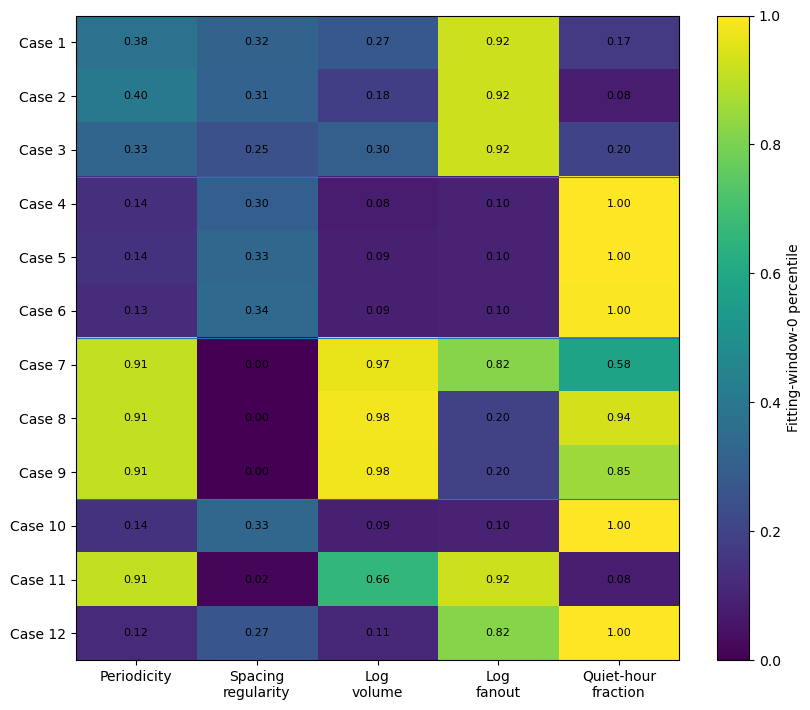

Saved: model_disagreement/Figure_03_disagreement_case_profiles.png


In [6]:
profile_cols = [f"{f}_pct" for f in CORE5]
profile_labels = [
    "Periodicity",
    "Spacing\nregularity",
    "Log\nvolume",
    "Log\nfanout",
    "Quiet-hour\nfraction",
]

matrix = cases[profile_cols].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(8.5, 7.2))
im = ax.imshow(matrix, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(profile_labels)))
ax.set_xticklabels(profile_labels)
ax.set_yticks(range(len(cases)))
ax.set_yticklabels([f"Case {i}" for i in cases["Case"]])

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=8)

for y in [2.5, 5.5, 8.5]:
    ax.axhline(y, linewidth=0.8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Fitting-window-0 percentile")

fig.tight_layout()
fig.savefig(FIGURE3_PATH, dpi=300, bbox_inches="tight")
fig.savefig(FIGURE3_PDF_PATH, bbox_inches="tight")
plt.show()

print("Saved:", FIGURE3_PATH)

## 6. Cross-window persistence — Supplementary Table 10

In [7]:
rank_pair_lookup = {
    "empirical_vs_kmeans": ("rank_empirical", "rank_kmeans"),
    "mixture_vs_kmeans": ("rank_mixture", "rank_kmeans"),
}

rows = []

for _, case in cases.iterrows():
    a_col, b_col = rank_pair_lookup[case["pair"]]

    traj = (
        scores.loc[
            scores["u"].astype(str) == str(case["u"]),
            ["win", a_col, b_col],
        ]
        .sort_values("win")
        .copy()
    )

    traj["gap"] = traj[a_col] - traj[b_col]
    w0_sign = np.sign(float(case["signed_gap"]))

    consistency = float(
        (np.sign(traj["gap"].to_numpy()) == w0_sign).mean()
    )

    rows.append({
        "Case": int(case["Case"]),
        "Direction": case["direction"],
        "Account": str(case["u"]),
        "Windows": int(len(traj)),
        "Consistency": consistency if len(traj) >= 2 else np.nan,
    })

table10 = pd.DataFrame(rows)
table10.to_csv(TABLE10_PATH, index=False)
display(table10.round(2))

,Case,Direction,Account,Windows,Consistency
0,1,Empirical rank > K-means,U5247@DOM1,4,1.00
1,2,Empirical rank > K-means,U5846@DOM1,4,1.00
2,3,Empirical rank > K-means,U7086@DOM1,4,1.00
3,4,K-means > Empirical rank,ANONYMOUS LOGON@C13508,1,NaN
4,5,K-means > Empirical rank,ANONYMOUS LOGON@C16073,1,NaN
5,6,K-means > Empirical rank,ANONYMOUS LOGON@C5902,1,NaN
6,7,Custom mixture > K-means,C13356$@DOM1,4,1.00
7,8,Custom mixture > K-means,C2070$@DOM1,4,1.00
8,9,Custom mixture > K-means,C2175$@DOM1,4,1.00
9,10,K-means > Custom mixture,ANONYMOUS LOGON@C16073,1,NaN


## 7. Raw-event context for Cases 7 and 12 — Supplementary Figure 10

These raw-event plots are examined only after the disagreement cases have been selected. They provide context for the prolonged inactive interval in Case 7 and the episodic lower-volume activity in Case 12.


Using existing auth_main.parquet
Success events: 1,038,590,151
Complete 14-day windows: 4
Discarded tail: 172799 seconds
DuckDB views restored: a, e


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

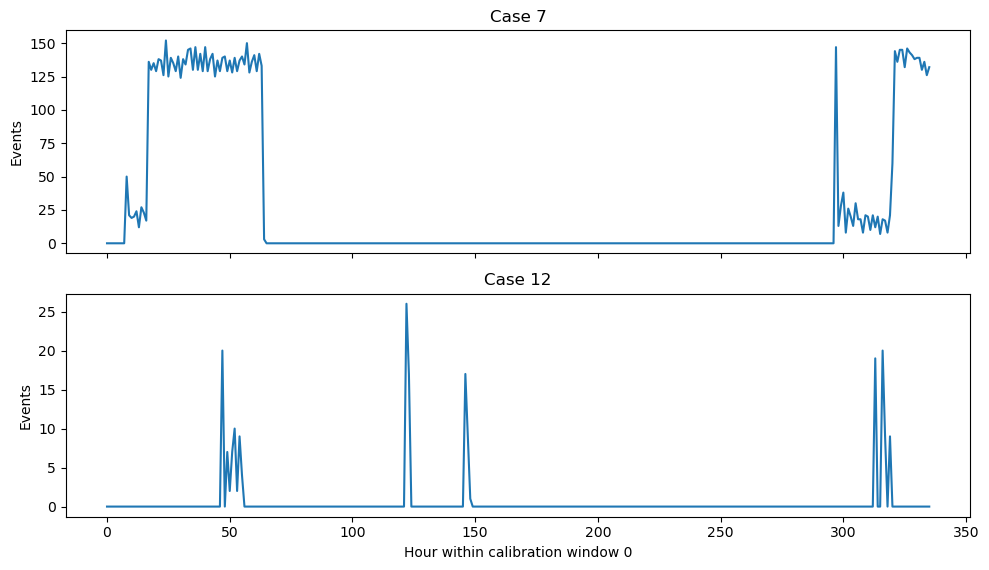

Saved: model_disagreement/Figure_10_disagreement_raw_activity.png


In [8]:
raw_case_map = {
    "Case 7": str(cases.loc[cases["Case"] == 7, "u"].iloc[0]),
    "Case 12": str(cases.loc[cases["Case"] == 12, "u"].iloc[0]),
}

selected_raw_users = pd.DataFrame({
    "u": list(raw_case_map.values())
})

con_raw, MAX_T, N_WIN = fu.initialise_duckdb(
    auth_parquet=AUTH_PARQUET,
    auth_path=AUTH_PATH,
    window_days=WINDOW_DAYS,
    force_auth_rebuild=False,
)

con_raw.register("_disagreement_raw_users", selected_raw_users)

raw_cases = con_raw.execute(
    f"""
    SELECT
        CAST(e.u AS VARCHAR) AS u,
        CAST(e.t AS BIGINT) AS t
    FROM e
    INNER JOIN _disagreement_raw_users AS s
      ON CAST(e.u AS VARCHAR) = s.u
    WHERE e.win = {PRIMARY_WINDOW}
    ORDER BY u, t
    """
).df()

con_raw.close()

account_to_case = {
    account: case_label
    for case_label, account in raw_case_map.items()
}
raw_cases["case_label"] = raw_cases["u"].map(account_to_case)
raw_cases["hour_bin"] = (raw_cases["t"] // 3600).astype(int)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 5.8),
    sharex=True,
)

for ax, case_label in zip(axes, ["Case 7", "Case 12"]):
    g = raw_cases.loc[
        raw_cases["case_label"] == case_label
    ]

    hourly = (
        g["hour_bin"]
        .value_counts()
        .reindex(range(WINDOW_DAYS * 24), fill_value=0)
        .sort_index()
    )

    ax.plot(hourly.index, hourly.values)
    ax.set_ylabel("Events")
    ax.set_title(case_label)

axes[-1].set_xlabel("Hour within calibration window 0")
fig.tight_layout()

fig.savefig(
    FIGURE10_PATH,
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE10_PDF_PATH,
    bbox_inches="tight",
)
plt.show()

print("Saved:", FIGURE10_PATH)

## 8. Exact K-means decomposition — Supplementary Table 11

For Cases 1, 7 and 12, the K-means distance-difference score is decomposed exactly by CORE5 feature.

In [9]:
km = scorers["kmeans_core5"]
rep_cases = cases.loc[cases["Case"].isin([1, 7, 12])].copy()

X = rep_cases[CORE5].copy()
for feature in CORE5:
    if feature in se.REVERSE_FEATURES:
        X[feature] = -X[feature]

X = X.fillna(km.medians_)
Z = km.scaler_.transform(X)

cM = km.model_.cluster_centers_[km.machine_id_]
cO = km.model_.cluster_centers_[1 - km.machine_id_]

dM = np.sqrt(((Z - cM) ** 2).sum(axis=1))
dO = np.sqrt(((Z - cO) ** 2).sum(axis=1))

contrib = (
    (Z - cO) ** 2 - (Z - cM) ** 2
) / (dO + dM)[:, None]

rows = []
for i, (_, case) in enumerate(rep_cases.iterrows()):
    for j, feature in enumerate(CORE5):
        rows.append({
            "Case": int(case["Case"]),
            "Feature": feature,
            "Contribution": float(contrib[i, j]),
        })
    rows.append({
        "Case": int(case["Case"]),
        "Feature": "Total dO-dM",
        "Contribution": float(dO[i] - dM[i]),
    })

table11 = pd.DataFrame(rows)
table11.to_csv(TABLE11_PATH, index=False)

display(
    table11.pivot(
        index="Feature",
        columns="Case",
        values="Contribution",
    ).round(3)
)

Case,1,7,12
Feature,,,
Total dO-dM,-1.986,-0.095,0.320
iat_cv,-0.035,-0.585,-0.043
log_fanout,0.078,0.018,0.030
log_volume,-0.430,0.150,-0.363
period_strength,-0.757,0.278,-0.371
quiet_frac,-0.842,0.045,1.068


## 9. Save provenance

The selected cases illustrate modelling differences; they are not used as population-level feature attribution.

In [10]:
meta = {
    "pipeline_stage": "03_model_disagreement",
    "upstream_model_stage": "02b_core5_model_comparison",
    "core5": CORE5,
    "primary_window": PRIMARY_WINDOW,
    "top_k": TOP_K,
    "mixture_disagreement_score": "log_likelihood_ratio",
    "models_refitted": False,
    "test_evaluated": False,
    "outputs": {
        "table_3": str(TABLE3_PATH),
        "figure_3": str(FIGURE3_PATH),
        "cases": str(CASES_PATH),
        "table_10": str(TABLE10_PATH),
        "figure_10": str(FIGURE10_PATH),
        "table_11": str(TABLE11_PATH),
        "score_resolution": str(SCORE_RESOLUTION_PATH),
    },
}
META_PATH.write_text(json.dumps(meta, indent=2))

print("Table 3 :", TABLE3_PATH)
print("Figure 3:", FIGURE3_PATH)
print("Table 10:", TABLE10_PATH)
print("Table 11:", TABLE11_PATH)
print("Metadata:", META_PATH)

Table 3 : model_disagreement/Table_03_model_rank_agreement.csv
Figure 3: model_disagreement/Figure_03_disagreement_case_profiles.png
Table 10: model_disagreement/Table_10_disagreement_persistence.csv
Table 11: model_disagreement/Table_11_kmeans_case_decomposition.csv
Metadata: model_disagreement/model_disagreement_meta.json
